# Magnetostatika: dari Gaya Lorentz hingga Potensial Vektor

**Elektrodinamika Klasik — Program Magister Fisika, Universitas Padjadjaran**

Notebook ini merangkum secara konseptual Bab 5 §§5.1–5.4 Griffiths, *Introduction to Electrodynamics*, edisi ke-4. Fokusnya adalah bagaimana arah vektor dan proyeksi komponen menentukan gaya serta medan magnet. Diagram dibuat ulang untuk pembelajaran; tidak menyalin ilustrasi buku.

Urutan: gaya Lorentz → arus → Biot–Savart → divergensi, curl, dan hukum Ampère → potensial vektor. Referensi halaman menggunakan **nomor halaman cetak buku** (hlm. 210–249), bukan nomor halaman penampil PDF.

## 1. Notasi, konvensi, dan tujuan belajar

Dalam notasi SI, medan magnet ditulis **vektor** tebal atau berpanah, misalnya $\mathbf B$. Komponen skalar ditulis $B_x,B_y,B_z$. Vektor posisi titik pengamatan adalah $\mathbf r=(x,y,z)$; titik sumber diberi tanda prima, $\mathbf r'=(x',y',z')$. Vektor dari sumber menuju pengamatan ialah

$$\mathbf R=\mathbf r-\mathbf r',\qquad R=|\mathbf R|,\qquad \hat{\mathbf R}=\mathbf R/R.$$

Tanda prima penting: integral sumber dilakukan atas koordinat berprima, sementara $\mathbf r$ menyatakan titik tempat medan dicari. Perkalian silang mengikuti orientasi tangan kanan: $\hat{\mathbf x}\times\hat{\mathbf y}=\hat{\mathbf z}$, dengan urutan terbalik menghasilkan tanda berlawanan.

Setelah bagian ini, Anda diharapkan dapat menentukan arah $q(\mathbf v\times\mathbf B)$, memilih komponen yang bertahan oleh simetri, dan menghubungkan $\mathbf B$ dengan $\mathbf A$.

**Konstanta permeabilitas.** Nilai $\mu_0=4\pi\times10^{-7}\,\mathrm{N/A^2}$ dipakai sebagai nilai konvensional edisi Griffiths. Sejak redefinisi SI 2019, nilai ini bukan lagi konstanta yang didefinisikan eksak; perhitungan notebook memakai nilai buku yang dibulatkan.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

mu0 = 4 * np.pi * 1e-7  # N/A^2; nilai yang dipakai pada edisi sumber
plt.rcParams.update({"figure.figsize": (8, 5), "font.size": 11})
print(f"mu0 = {mu0:.6g} N/A^2; 1 T = 1 N/(A m)")

mu0 = 1.25664e-06 N/A^2; 1 T = 1 N/(A m)


## 2. Hukum gaya Lorentz: arah ditentukan oleh perkalian silang

Gaya pada muatan uji $q$ yang bergerak dengan kecepatan $\mathbf v$ dalam medan listrik dan magnet adalah

$$\mathbf F=q(\mathbf E+\mathbf v\times\mathbf B),\qquad \mathbf F_{\rm mag}=q\,\mathbf v\times\mathbf B.$$

Besar gaya magnet $|q|vB\sin\theta$ hanya bergantung pada komponen kecepatan yang tegak lurus $\mathbf B$: $v_\perp=v\sin\theta$. Komponen sejajar medan tidak menghasilkan gaya. Arah $\mathbf v\times\mathbf B$ berlaku untuk $q>0$; muatan negatif membalik arah gaya. Karena $\mathbf F_{\rm mag}\cdot\mathbf v=0$, gaya magnet sesaat tidak mengubah laju/energi kinetik partikel, meski dapat membelokkan lintasannya. (Griffiths §5.1.2, hlm. 212–216.)

### Penurunan komponen dan pembacaan arah pada diagram

Hukum Lorentz adalah **hukum dasar empiris**: bentuk cross product menyatakan hasil eksperimen dan mengkodekan besar serta arah gaya. Dengan input umum $\mathbf v=(v_x,v_y,v_z)$ dan $\mathbf B=(B_x,B_y,B_z)$, hitung komponen output sebagai

$$
\mathbf v\times\mathbf B=
\begin{vmatrix}
\hat{\mathbf x}&\hat{\mathbf y}&\hat{\mathbf z}\\
v_x&v_y&v_z\\
B_x&B_y&B_z
\end{vmatrix}
=(v_yB_z-v_zB_y)\hat{\mathbf x}+(v_zB_x-v_xB_z)\hat{\mathbf y}+(v_xB_y-v_yB_x)\hat{\mathbf z}.
$$

**Cocokkan input dan output dengan gambar di atas.** Sumbu $x$ ke kanan, $y$ ke atas, dan $+z$ keluar bidang (simbol titik). Gambar memasukkan $\mathbf v=v\hat{\mathbf x}$ dan $\mathbf B=B\hat{\mathbf z}$, sehingga

$$\mathbf v\times\mathbf B=vB(\hat{\mathbf x}\times\hat{\mathbf z})=-vB\hat{\mathbf y},\qquad \mathbf F_{\rm mag}=-qvB\hat{\mathbf y}\quad(q>0).$$

Jadi panah output gaya untuk $q>0$ memang ke bawah; untuk $q<0$, hasil dikalikan muatan negatif dan arahnya ke atas. Jika ada komponen kecepatan sejajar $\mathbf B$, komponen itu tidak muncul dalam determinan setelah cross product. Besarnya dapat dibaca lewat proyeksi $v_\perp=v\sin\theta$: $|\mathbf F_{\rm mag}|=|q|Bv_\perp$.


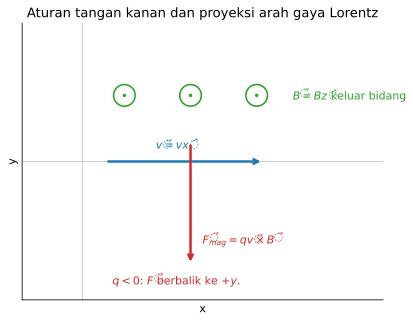

In [2]:
# Proyeksi 2D: v ke kanan (+x), B keluar bidang (+z), maka v x B = -y.
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_aspect("equal")
ax.set_xlim(-1, 5); ax.set_ylim(-2.3, 2.3)
ax.axhline(0, color="0.8", lw=1); ax.axvline(0, color="0.8", lw=1)
ax.annotate("", (3.0, 0), (0.4, 0), arrowprops={"arrowstyle": "->", "lw": 2.5, "color": "C0"})
ax.text(1.5, 0.2, r"$\vec v=v\hat x$", color="C0", ha="center")
ax.annotate("", (1.8, -1.7), (1.8, 0.3), arrowprops={"arrowstyle": "->", "lw": 2.5, "color": "C3"})
ax.text(2.0, -1.3, r"$\vec F_{mag}=q\vec v\times\vec B$", color="C3", va="center")
for x, y in [(0.7, 1.1), (1.8, 1.1), (2.9, 1.1)]:
    ax.add_patch(Circle((x, y), 0.18, fill=False, color="C2", lw=1.6))
    ax.plot(x, y, ".", color="C2", ms=5)
ax.text(3.5, 1.1, r"$\vec B=B\hat z$ keluar bidang", color="C2", va="center")
ax.text(0.5, -2.05, r"$q<0$: $\vec F$ berbalik ke $+y$.", color="C3")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Aturan tangan kanan dan proyeksi arah gaya Lorentz")
ax.set_xticks([]); ax.set_yticks([]); ax.spines[["top", "right"]].set_visible(False)
plt.show()

### Proyeksi kecepatan dan besar gaya

Jika $\mathbf B=B\hat{\mathbf z}$ dan $\mathbf v=v_x\hat{\mathbf x}+v_y\hat{\mathbf y}+v_z\hat{\mathbf z}$, maka

$$\mathbf v\times\mathbf B=B(v_y\hat{\mathbf x}-v_x\hat{\mathbf y}),\qquad F_{\rm mag}=|q|B\sqrt{v_x^2+v_y^2}.$$

Komponen $v_z$ sejajar medan hilang dari hasil silang. Secara umum, proyeksikan $\mathbf v$ menjadi $\mathbf v_\parallel+\mathbf v_\perp$; hanya $\mathbf v_\perp$ yang menentukan gaya. Ini juga menjelaskan mengapa gerak dalam medan seragam dapat berupa heliks: gerak melingkar dari komponen tegak lurus ditambah gerak lurus dari komponen sejajar.

## 3. Arus dan gaya pada pembawa arus

Arus konvensional berarah seperti aliran muatan positif. Untuk kawat, $I$ adalah muatan yang melintasi penampang per satuan waktu; pada rumus elemen kawat, $I$ biasanya besar arus dan $d\boldsymbol\ell$ dipilih searah arus. Rapat arus volume $\mathbf J$ (A/m$^2$) dan rapat arus permukaan $\mathbf K$ (A/m) adalah vektor.

Penjumlahan gaya Lorentz atas muatan bergerak menghasilkan bentuk kontinu

$$d\mathbf F=I\,d\boldsymbol\ell\times\mathbf B,\qquad \mathbf f=\mathbf J\times\mathbf B.$$

Di sini $d\boldsymbol\ell$ berarah sama dengan arus konvensional dan $\mathbf f$ adalah gaya per volume. Untuk arus tunak, tidak ada akumulasi muatan lokal: persamaan kontinuitas $\partial\rho/\partial t+\nabla\cdot\mathbf J=0$ menjadi $\nabla\cdot\mathbf J=0$. (Griffiths §5.1.3 dan §5.2.1, hlm. 216–224.)

### Dari gaya satu muatan ke gaya pada kawat

Ambil segmen lurus kecil dengan rapat muatan bergerak linear $\lambda$ dan kecepatan pembawa $\mathbf v=v\hat{\mathbf t}$ searah arus konvensional. Muatan pada panjang $d\ell$ adalah $dq=\lambda d\ell$, sedangkan $I=\lambda v$. Karena itu

$$d\mathbf F=(dq\,\mathbf v)\times\mathbf B=(\lambda d\ell\,v\hat{\mathbf t})\times\mathbf B=I\,d\boldsymbol\ell\times\mathbf B.$$

Urutan input cross product ialah **elemen arus dahulu, medan kemudian**. Untuk medan konstan, integralkan sepanjang kawat: $\mathbf F=I\int d\boldsymbol\ell\times\mathbf B$. Untuk arus volume, muatan bergerak per volume menghasilkan gaya per volume $\mathbf f=\mathbf J\times\mathbf B$ (N/m$^3$), sehingga $d\mathbf F=\mathbf f\,d\tau$.


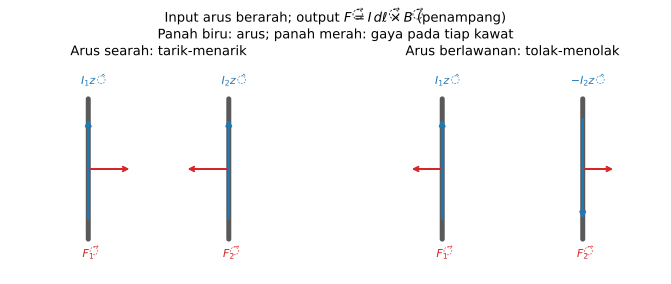

In [3]:
# Dua kawat sejajar: arus searah menarik; arus berlawanan arah menolak.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, same, title in [(axes[0], True, "Arus searah: tarik-menarik"), (axes[1], False, "Arus berlawanan: tolak-menolak")]:
    ax.set_aspect("equal"); ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1, 1)
    for x, up in [(-0.65, True), (0.65, same)]:
        ax.plot([x, x], [-0.65, 0.65], color="0.35", lw=5, solid_capstyle="round")
        ax.annotate("", (x, 0.48 if up else -0.48), (x, -0.48 if up else 0.48),
                    arrowprops={"arrowstyle": "->", "lw": 2.5, "color": "C0"})
    ax.annotate("", (-0.25 if same else -0.95, 0), (-0.65, 0), arrowprops={"arrowstyle": "->", "lw": 2, "color": "C3"})
    ax.annotate("", (0.25 if same else 0.95, 0), (0.65, 0), arrowprops={"arrowstyle": "->", "lw": 2, "color": "C3"})
    ax.text(-0.65, 0.78, r"$I_1\hat z$", ha="center", color="C0")
    ax.text(0.65, 0.78, r"$I_2\hat z$" if same else r"$-I_2\hat z$", ha="center", color="C0")
    ax.text(-0.65, -0.82, r"$\vec F_1$", ha="center", color="C3")
    ax.text(0.65, -0.82, r"$\vec F_2$", ha="center", color="C3")
    ax.set_title(title); ax.axis("off")
fig.suptitle(r"Input arus berarah; output $\vec F=I\,d\vec\ell\times\vec B$ (penampang)" + "\nPanah biru: arus; panah merah: gaya pada tiap kawat")
plt.tight_layout(); plt.show()

## 4. Hukum Biot–Savart: kontribusi tiap elemen sumber

Untuk elemen kawat berarus tunak dan untuk distribusi arus volume,

$$d\mathbf B(\mathbf r)=\frac{\mu_0}{4\pi}\frac{I\,d\boldsymbol\ell'\times\hat{\mathbf R}}{R^2},\qquad
\mathbf B(\mathbf r)=\frac{\mu_0}{4\pi}\int\frac{\mathbf J(\mathbf r')\times\hat{\mathbf R}}{R^2}\,d\tau'.$$

Arah $d\mathbf B$ tegak lurus bidang yang dibentuk $d\boldsymbol\ell'$ dan $\mathbf R$, bukan sepanjang garis sumber–pengamat. Besar elemennya sebanding $\sin\theta$, sehingga kontribusi nol jika kedua vektor sejajar. Integrasi menjumlahkan kontribusi sebagai **vektor**. (Griffiths §5.2.2, hlm. 224–228.)

### Membaca vektor sumber dan medan pada sketsa

Untuk elemen garis, inputnya adalah arus skalar positif $I$, elemen vektor $d\boldsymbol\ell'$ **searah arus**, dan vektor pemisah $\mathbf R=\mathbf r-\mathbf r'$ **dari elemen sumber ke titik medan**. Output $d\mathbf B$ tegak lurus kedua input:

$$d\mathbf B=\frac{\mu_0 I}{4\pi}\frac{d\boldsymbol\ell'\times\hat{\mathbf R}}{R^2}=\frac{\mu_0 I}{4\pi}\frac{d\boldsymbol\ell'\times\mathbf R}{R^3}.$$

Pada diagram di bawah, kawat dan $d\boldsymbol\ell'$ menunjuk $+z$, titik medan ada di $+x$, maka bagian $+x$ pada $\mathbf R$ memberi $\hat{\mathbf z}\times\hat{\mathbf x}=+\hat{\mathbf y}$. Komponen $\mathbf R$ sejajar $z$ tidak berkontribusi karena $\hat{\mathbf z}\times\hat{\mathbf z}=0$; jadi simbol titik (keluar bidang) untuk $d\mathbf B$ konsisten dengan input gambar. Membalik arus membalik output. Untuk distribusi volume, jumlahkan elemen sumber $\mathbf J(\mathbf r')d\tau'$:

$$\mathbf B(\mathbf r)=\frac{\mu_0}{4\pi}\int\frac{\mathbf J(\mathbf r')\times\hat{\mathbf R}}{R^2}\,d\tau'.$$


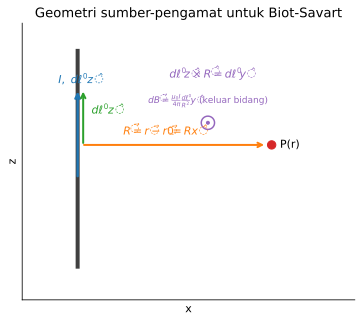

In [4]:
# Geometri elemen kawat sejajar z dan titik pengamatan pada jarak s di x.
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_aspect("equal"); ax.set_xlim(-1, 5); ax.set_ylim(-1, 4)
ax.plot([0, 0], [-0.4, 3.5], color="0.25", lw=4)
ax.annotate("", (0, 2.8), (0, 1.2), arrowprops={"arrowstyle": "->", "lw": 2.4, "color": "C0"})
ax.text(-0.35, 2.9, r"$I,\ d\ell'\,\hat z$", color="C0")
ax.scatter([3.5], [1.8], s=70, color="C3", zorder=4); ax.text(3.65, 1.8, "P(r)", va="center")
ax.annotate("", (3.4, 1.8), (0.08, 1.8), arrowprops={"arrowstyle": "->", "lw": 2, "color": "C1"})
ax.text(1.5, 1.98, r"$\vec R=\vec r-\vec r\prime=R\hat x$", color="C1", ha="center")
ax.annotate("", (0.1, 2.8), (0.1, 1.8), arrowprops={"arrowstyle": "->", "lw": 2, "color": "C2"})
ax.text(0.25, 2.35, r"$d\ell'\,\hat z$", color="C2")
ax.text(2.35, 3.0, r"$d\ell'\hat z\times\hat R=d\ell'\hat y$", color="C4", ha="center")
ax.text(2.35, 2.55, r"$d\vec B=\frac{\mu_0 I}{4\pi}\frac{d\ell'}{R^2}\hat y$ (keluar bidang)", color="C4", ha="center", fontsize=9)
ax.add_patch(Circle((2.35, 2.2), 0.12, fill=False, color="C4", lw=1.5)); ax.plot(2.35, 2.2, ".", color="C4")
ax.set_xlabel("x"); ax.set_ylabel("z"); ax.set_title("Geometri sumber-pengamat untuk Biot-Savart")
ax.set_xticks([]); ax.set_yticks([]); ax.spines[["top", "right"]].set_visible(False)
plt.show()

### Contoh 1 — kawat lurus tak hingga

Ambil kawat sepanjang sumbu $z$ dengan arus $+z$, dan titik pengamatan berjarak tegak lurus $s$. Simetri silinder memaksa medan melingkar mengitari kawat. Dalam koordinat silinder, $\hat{\boldsymbol\phi}=\hat{\mathbf z}\times\hat{\mathbf s}$; integral Biot–Savart memberi

$$\mathbf B(s)=\frac{\mu_0 I}{2\pi s}\,\hat{\boldsymbol\phi}.$$

Untuk melihat proyeksi, pada titik sumbu $+x$ arah $\hat{\boldsymbol\phi}=+\hat y$. Setiap elemen kawat memberi arah tangensial ini; besar kontribusinya berubah sepanjang kawat tetapi arahnya sama pada sumbu tersebut. Membalik arus membalik $\mathbf B$.

### Turunan dari elemen sumber sampai medan total

Pilih sumber pada kawat sebagai $\mathbf r'=z'\hat{\mathbf z}$ dan titik pengamatan $\mathbf r=s\hat{\mathbf x}$. Dengan arus $I$ ke $+z$,

$$d\boldsymbol\ell'=dz'\hat{\mathbf z},\quad \mathbf R=s\hat{\mathbf x}-z'\hat{\mathbf z},\quad R=\sqrt{s^2+z'^2}.$$

Substitusi **input vektor** ke Biot–Savart (bentuk $\mathbf R/R^3$):

$$d\mathbf B=\frac{\mu_0I}{4\pi}\frac{dz'\hat{\mathbf z}\times(s\hat{\mathbf x}-z'\hat{\mathbf z})}{(s^2+z'^2)^{3/2}}=\frac{\mu_0I}{4\pi}\frac{s\,dz'}{(s^2+z'^2)^{3/2}}\hat{\mathbf y}.$$

Semua elemen memiliki arah output $+y$, sehingga integral tinggal menjumlahkan besar kontribusinya. Dengan $u=z'/s$,

$$\mathbf B=\frac{\mu_0I}{4\pi}\hat{\mathbf y}\int_{-\infty}^{\infty}\frac{s\,dz'}{(s^2+z'^2)^{3/2}}=\frac{\mu_0I}{4\pi s}\hat{\mathbf y}\int_{-\infty}^{\infty}\frac{du}{(1+u^2)^{3/2}}=\frac{\mu_0I}{2\pi s}\hat{\mathbf y}.$$

Ini adalah medan pada sumbu $+x$; bentuk di titik umum silinder ialah $\mathbf B=(\mu_0I/2\pi s)\hat{\boldsymbol\phi}$. Nilai $\hat{\boldsymbol\phi}=+\hat{\mathbf y}$ tepat di $+x$, sesuai sketsa arah medan.


I = 2 A, s = 0.04 m -> |B| = 1.000e-05 T


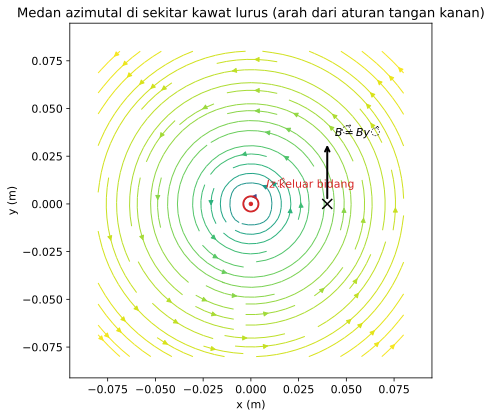

In [5]:
I, s = 2.0, 0.04
Bmag = mu0 * I / (2 * np.pi * s)
print(f"I = {I:g} A, s = {s:g} m -> |B| = {Bmag:.3e} T")

fig, ax = plt.subplots(figsize=(6.5, 6.5))
xx = np.linspace(-0.08, 0.08, 17); yy = np.linspace(-0.08, 0.08, 17)
X, Y = np.meshgrid(xx, yy); R2 = X**2 + Y**2
U = -Y / np.maximum(R2, 1e-6); V = X / np.maximum(R2, 1e-6)
ax.streamplot(X, Y, U, V, density=1.0, color=np.log(np.sqrt(np.maximum(R2, 1e-6))), cmap="viridis", linewidth=1)
ax.add_patch(Circle((0, 0), 0.004, fill=False, color="C3", lw=1.8, zorder=4))
ax.plot(0, 0, ".", color="C3", ms=7, zorder=5)
ax.text(0.008, 0.008, r"$I\hat z$ keluar bidang", color="C3")
ax.scatter([s], [0], marker="x", s=100, color="black", zorder=5)
ax.annotate("", (s, 0.032), (s, 0.002), arrowprops={"arrowstyle": "->", "lw": 2, "color": "black"})
ax.text(s + 0.004, 0.034, r"$\vec B=B\hat y$", va="bottom")
ax.set_aspect("equal"); ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_title("Medan azimutal di sekitar kawat lurus (arah dari aturan tangan kanan)")
plt.show()

### Contoh 2 — loop lingkaran, proyeksi medan ke sumbu

Pada titik di sumbu loop berjari-jari $R$, jarak dari setiap elemen ke titik pengamatan sama, $r=\sqrt{R^2+z^2}$. Pasangan elemen yang berhadapan menghasilkan komponen radial yang sama besar tetapi berlawanan arah; komponen radial **saling meniadakan**. Komponen sumbu $z$ searah dan dijumlahkan. Hasilnya

$$\mathbf B(z)=\frac{\mu_0 I R^2}{2(R^2+z^2)^{3/2}}\,\hat{\mathbf z}.$$

Ini contoh penting: proyeksi bukan sekadar menggambar panah, tetapi memilih komponen yang bertahan setelah integrasi simetris. (Griffiths §5.2.2, contoh loop pada hlm. 226–227.)

### Turunan loop: proyeksikan sebelum mengintegralkan

Letakkan loop berjari-jari $a$ di bidang $xy$, pusat di asal, arus berlawanan arah jarum jam jika dilihat dari $+z$, dan pengamat di $\mathbf r=z\hat{\mathbf z}$. Elemen sumber pada sudut $\phi$ dan input vektornya adalah

$$\mathbf r'=a\hat{\boldsymbol\rho}',\quad d\boldsymbol\ell'=a\,d\phi\,\hat{\boldsymbol\phi}',\quad \mathbf R=-a\hat{\boldsymbol\rho}'+z\hat{\mathbf z},\quad R=\sqrt{a^2+z^2}.$$

Dari identitas basis silinder $\hat{\boldsymbol\phi}'\times\hat{\boldsymbol\rho}'=-\hat{\mathbf z}$ dan $\hat{\boldsymbol\phi}'\times\hat{\mathbf z}=\hat{\boldsymbol\rho}'$:

$$d\boldsymbol\ell'\times\mathbf R=a\,d\phi\left(a\hat{\mathbf z}+z\hat{\boldsymbol\rho}'\right),\quad d\mathbf B=\frac{\mu_0I a\,d\phi}{4\pi(a^2+z^2)^{3/2}}\left(a\hat{\mathbf z}+z\hat{\boldsymbol\rho}'\right).$$

Komponen output radial $z\hat{\boldsymbol\rho}'$ saling meniadakan untuk elemen berseberangan ($\phi$ dan $\phi+\pi$), sedangkan proyeksi $+z$ sama arah untuk seluruh loop. Maka

$$\mathbf B(z)=\frac{\mu_0I a^2}{4\pi(a^2+z^2)^{3/2}}\int_0^{2\pi}d\phi\,\hat{\mathbf z}=\frac{\mu_0I a^2}{2(a^2+z^2)^{3/2}}\hat{\mathbf z}.$$

**Orientasi sketsa proyeksi:** bidang gambar adalah $xz$; sumbu $y$ tegak lurus kertas. Pada titik kawat $+x$, arus CCW mengarah $+y$ (titik/keluar kertas); di $-x$, arus mengarah $-y$ (silang/masuk kertas). Panah kontribusi di titik $P$ karenanya memiliki proyeksi radial berlawanan, tetapi komponen vertikal $+z$ sama.


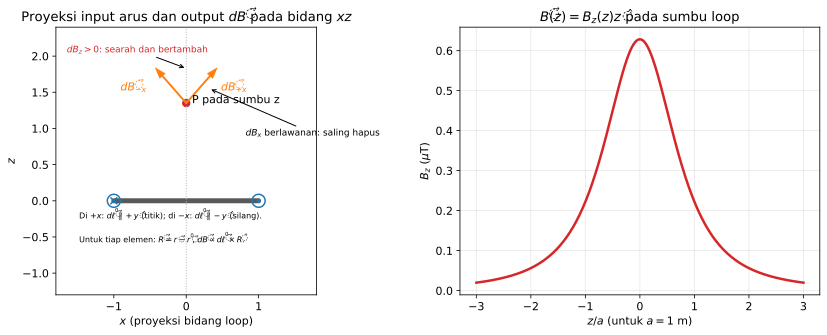

In [6]:
R, Iloop = 1.0, 1.0
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ax = axes[0]; ax.set_aspect("equal")
ax.plot([-R, R], [0, 0], color="0.35", lw=5, solid_capstyle="round")
for x0, sign in [(-R, -1), (R, 1)]:
    ax.add_patch(Circle((x0, 0), 0.09, fill=False, color="C0", lw=1.5, zorder=3))
    if sign > 0:
        ax.plot(x0, 0, ".", color="C0", ms=6, zorder=4)  # +y keluar bidang
    else:
        ax.plot([x0-0.04, x0+0.04], [-0.04, 0.04], color="C0", lw=1.5, zorder=4)
        ax.plot([x0-0.04, x0+0.04], [0.04, -0.04], color="C0", lw=1.5, zorder=4)  # -y masuk bidang
ax.axvline(0, color="0.7", ls=":", lw=1)
ax.scatter([0], [1.35], color="C3", s=55); ax.text(0.08, 1.35, "P pada sumbu z")
ax.arrow(0, 1.35, -0.42, 0.48, width=0.012, head_width=0.09, color="C1", length_includes_head=True)
ax.arrow(0, 1.35, 0.42, 0.48, width=0.012, head_width=0.09, color="C1", length_includes_head=True)
ax.text(-0.55, 1.52, r"$d\vec B_{-x}$", color="C1", ha="right")
ax.text(0.48, 1.52, r"$d\vec B_{+x}$", color="C1", ha="left")
ax.annotate(r"$dB_x$ berlawanan: saling hapus", (0.32, 1.55), (0.82, 0.9), arrowprops={"arrowstyle": "->"}, fontsize=9)
ax.annotate(r"$dB_z>0$: searah dan bertambah", (0, 1.83), (-1.65, 2.05), arrowprops={"arrowstyle": "->"}, fontsize=9, color="C3")
ax.text(-1.48, -0.25, r"Di $+x$: $d\vec\ell'\parallel+\hat y$ (titik); di $-x$: $d\vec\ell'\parallel-\hat y$ (silang).", fontsize=8)
ax.text(-1.48, -0.58, r"Untuk tiap elemen: $\vec R=\vec r-\vec r'$, $d\vec B\propto d\vec\ell'\times\hat R$.", fontsize=8)
ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.3, 2.4); ax.set_xlabel(r"$x$ (proyeksi bidang loop)"); ax.set_ylabel(r"$z$")
ax.set_title(r"Proyeksi input arus dan output $d\vec B$ pada bidang $xz$")
z = np.linspace(-3, 3, 400)
Bz = mu0*Iloop*R**2/(2*(R**2+z**2)**1.5)
axes[1].plot(z, Bz*1e6, color="C3", lw=2.5)
axes[1].set_xlabel(r"$z/a$ (untuk $a=1$ m)"); axes[1].set_ylabel(r"$B_z$ ($\mu$T)")
axes[1].set_title(r"$\vec B(z)=B_z(z)\hat z$ pada sumbu loop")
axes[1].grid(alpha=0.3); plt.tight_layout(); plt.show()

## 5. Divergensi, curl, dan hukum Ampère

Dalam magnetostatika, hukum lokal medan adalah

$$\nabla\cdot\mathbf B=0,\qquad \nabla\times\mathbf B=\mu_0\mathbf J.$$

Divergensi nol menyatakan tidak ada sumber/tenggelam titik bagi garis $\mathbf B$ (tidak ada monopole magnet dalam model ini); garis medan tidak berawal atau berakhir pada muatan magnet. Curl menyatakan arus tunak merupakan sumber sirkulasi medan. Dengan teorema Stokes, bentuk kedua menjadi

$$\oint_C\mathbf B\cdot d\boldsymbol\ell=\mu_0 I_{\rm enc},\qquad I_{\rm enc}=\int_S\mathbf J\cdot d\mathbf a.$$

Arah normal $d\mathbf a$ dan arah keliling $C$ harus konsisten aturan tangan kanan: ibu jari sepanjang normal positif, jari melengkung sepanjang lintasan positif. Ampère sangat efisien jika simetri membuat $\mathbf B$ konstan dan sejajar/tegak lurus di bagian lintasan yang dipilih; jika tidak, gunakan Biot–Savart. Hukum lokal ini berlaku untuk arus tunak, bukan bentuk lengkap untuk medan berubah waktu. (Griffiths §5.3, hlm. 229–242.)

### Turunan bentuk integral dan orientasi normal

Mulai dari persamaan lokal $\nabla\times\mathbf B=\mu_0\mathbf J$. Integralkan pada permukaan $S$ ber-normal positif $d\mathbf a$ dan terapkan teorema Stokes:

$$\int_S(\nabla\times\mathbf B)\cdot d\mathbf a=\oint_{\partial S}\mathbf B\cdot d\boldsymbol\ell=\mu_0\int_S\mathbf J\cdot d\mathbf a=\mu_0I_{\rm enc}.$$

Aturan orientasi pada gambar: ibu jari menuju normal $+z$ (arus terhitung positif), jari melengkung berlawanan arah jarum jam menentukan arah lintasan positif. Untuk kawat lurus pada sumbu $z$ dan lintasan lingkaran radius $s$, simetri memberi $\mathbf B=B_\phi\hat{\boldsymbol\phi}$ konstan; karena sejajar lintasan,

$$B_\phi\oint d\ell=B_\phi(2\pi s)=\mu_0I\quad\Rightarrow\quad\mathbf B=\frac{\mu_0I}{2\pi s}\hat{\boldsymbol\phi}.$$

Jika lintasan tidak memiliki simetri yang membuat $B$ konstan/sejajar, persamaan Ampère tetap benar tetapi tidak cukup sendirian untuk menentukan $\mathbf B$ dengan mudah.


Integral B dl = 1.884956e-06 T m; mu0 I = 1.884956e-06 T m


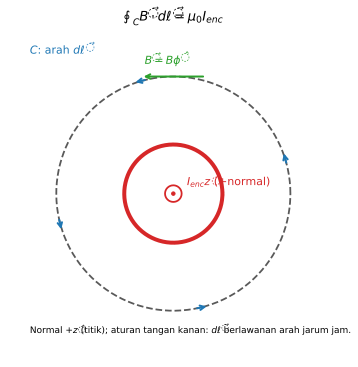

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.set_aspect("equal"); ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.2, 2.2)
theta = np.linspace(0, 2*np.pi, 240)
ax.plot(0.65*np.cos(theta), 0.65*np.sin(theta), color="C3", lw=4)
ax.add_patch(Circle((0, 0), 0.11, fill=False, color="C3", lw=1.8)); ax.plot(0, 0, ".", color="C3", ms=7)
ax.text(0.18, 0.1, r"$I_{enc}\hat z$ (+normal)", color="C3")
radius = 1.55
ax.plot(radius*np.cos(theta), radius*np.sin(theta), "--", color="0.35", lw=1.8)
for t in [0.25, 1.8, 3.35, 4.9]:
    x, y = radius*np.cos(t), radius*np.sin(t)
    ax.annotate("", (x-0.18*np.sin(t), y+0.18*np.cos(t)), (x, y), arrowprops={"arrowstyle": "->", "color": "C0", "lw": 2})
ax.text(-1.9, 1.85, r"$C$: arah $d\vec\ell$", color="C0")
ax.annotate("", (-0.42, radius), (0.42, radius), arrowprops={"arrowstyle": "->", "color": "C2", "lw": 2})
ax.text(-0.38, radius+0.16, r"$\vec B=B\hat\phi$", color="C2")
ax.text(-1.9, -1.85, r"Normal $+\hat z$ (titik); aturan tangan kanan: $d\vec\ell$ berlawanan arah jarum jam.", fontsize=9)
ax.set_title(r"$\oint_C\vec B\cdot d\vec\ell=\mu_0 I_{enc}$")
ax.axis("off"); plt.show()

# Uji hasil untuk lintasan lingkaran berjari-jari s di sekitar kawat lurus:
Itest, stest = 1.5, 0.03
Btest = mu0*Itest/(2*np.pi*stest)
lhs = Btest*(2*np.pi*stest)
rhs = mu0*Itest
print(f"Integral B dl = {lhs:.6e} T m; mu0 I = {rhs:.6e} T m")

## 6. Potensial vektor magnet

Karena $\nabla\cdot\mathbf B=0$, medan magnet dapat ditulis sebagai curl suatu medan vektor:

$$\mathbf B=\nabla\times\mathbf A.$$

Identitas $\nabla\cdot(\nabla\times\mathbf A)=0$ membuat syarat tanpa monopole otomatis terpenuhi. Potensial vektor tidak tunggal: untuk fungsi skalar $\chi$, transformasi

$$\mathbf A'=\mathbf A+\nabla\chi$$

tidak mengubah medan karena $\nabla\times\nabla\chi=0$. Kebebasan ini disebut kebebasan gauge. Pilihan Coulomb $\nabla\cdot\mathbf A=0$ menyederhanakan hukum Ampère menjadi persamaan Poisson (komponen Kartesius):

$$\nabla^2\mathbf A=-\mu_0\mathbf J,\qquad
\mathbf A(\mathbf r)=\frac{\mu_0}{4\pi}\int\frac{\mathbf J(\mathbf r')}{|\mathbf r-\mathbf r'|}\,d\tau'.$$

Untuk arus garis, $\mathbf A(\mathbf r)=\frac{\mu_0 I}{4\pi}\int d\boldsymbol\ell'/R$. Medan yang terukur adalah $\mathbf B$; $\mathbf A$ adalah representasi yang bergantung gauge dan tidak boleh disamakan dengan $\mathbf B$. (Griffiths §5.4.1, hlm. 243–249.)

### Turunan persamaan Poisson untuk $\mathbf A$

Mulai dari definisi $\mathbf B=\nabla\times\mathbf A$ dan identitas curl-curl:

$$\nabla\times\mathbf B=\nabla\times(\nabla\times\mathbf A)=\nabla(\nabla\cdot\mathbf A)-\nabla^2\mathbf A.$$

Kebebasan gauge $\mathbf A'=\mathbf A+\nabla\chi$ membolehkan gauge Coulomb $\nabla\cdot\mathbf A=0$. Persamaan Ampère magnetostatik lalu menjadi

$$\nabla\times\mathbf B=\mu_0\mathbf J\quad\Rightarrow\quad-\nabla^2\mathbf A=\mu_0\mathbf J\quad\Rightarrow\quad\nabla^2\mathbf A=-\mu_0\mathbf J.$$

Ini adalah persamaan Poisson untuk tiap komponen **Kartesius** $A_x,A_y,A_z$. Dengan syarat medan potensial meluruh sesuai solusi Green di tak hingga, inversi Poisson memberi

$$\mathbf A(\mathbf r)=\frac{\mu_0}{4\pi}\int\frac{\mathbf J(\mathbf r')}{|\mathbf r-\mathbf r'|}\,d\tau'.$$

Untuk kawat garis, gantikan $\mathbf Jd\tau'$ dengan $I\,d\boldsymbol\ell'$ sehingga $\mathbf A=(\mu_0I/4\pi)\int d\boldsymbol\ell'/R$. Setelah memperoleh $\mathbf A$, ambil curl (dengan turunan terhadap koordinat pengamatan yang tidak berprima) untuk mendapatkan output medan $\mathbf B$. Pada grafik kawat, input $\mathbf A=A_z(s)\hat{\mathbf z}$ memberi $B_\phi=-dA_z/ds$; nilai $A_z$ sendiri bergantung gauge.


Menambahkan konstanta pada Az (setara gradien fungsi linear z) tidak mengubah curl A.


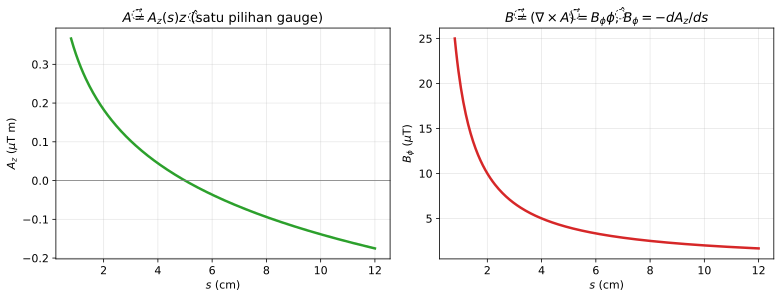

In [8]:
# Ilustrasi untuk kawat tak hingga: satu pilihan gauge Coulomb adalah
# A = Az(s) zhat, Az = -(mu0 I/2pi) ln(s/s0); curl A menghasilkan B_phi > 0.
I, s0 = 1.0, 0.05
s = np.linspace(0.008, 0.12, 250)
Az = -(mu0*I/(2*np.pi))*np.log(s/s0)
Bphi = mu0*I/(2*np.pi*s)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].plot(s*100, Az*1e6, color="C2", lw=2.5)
axes[0].axhline(0, color="0.5", lw=0.8)
axes[0].set_xlabel(r"$s$ (cm)"); axes[0].set_ylabel(r"$A_z$ ($\mu$T m)")
axes[0].set_title(r"$\vec A=A_z(s)\hat z$ (satu pilihan gauge)")
axes[0].grid(alpha=0.3)
axes[1].plot(s*100, Bphi*1e6, color="C3", lw=2.5)
axes[1].set_xlabel(r"$s$ (cm)"); axes[1].set_ylabel(r"$B_\phi$ ($\mu$T)")
axes[1].set_title(r"$\vec B=(\nabla\times\vec A)=B_\phi\hat\phi$, $B_\phi=-dA_z/ds$")
axes[1].grid(alpha=0.3); plt.tight_layout(); plt.show()
print("Menambahkan konstanta pada Az (setara gradien fungsi linear z) tidak mengubah curl A.")

## 7. Peta konsep dan ringkasan penggunaan

| Gagasan | Persamaan kunci | Kapan/apa maknanya |
|---|---|---|
| Gaya magnet pada muatan | $\mathbf F_{\rm mag}=q\mathbf v\times\mathbf B$ | Arah dari tangan kanan untuk $q>0$; hanya $v_\perp$ memberi gaya |
| Gaya pada arus | $d\mathbf F=I\,d\boldsymbol\ell\times\mathbf B$ | Gaya total kawat adalah integral sepanjang elemen arus |
| Biot–Savart | $d\mathbf B=\frac{\mu_0 I}{4\pi}\frac{d\boldsymbol\ell'\times\hat{\mathbf R}}{R^2}$ | Menghitung kontribusi vektor untuk geometri umum |
| Sumber magnetostatik | $\nabla\cdot\mathbf B=0$, $\nabla\times\mathbf B=\mu_0\mathbf J$ | Tidak ada sumber titik magnet; arus menghasilkan curl medan |
| Hukum Ampère | $\oint\mathbf B\cdot d\boldsymbol\ell=\mu_0 I_{\rm enc}$ | Pilih lintasan simetri agar integral mudah |
| Potensial vektor | $\mathbf B=\nabla\times\mathbf A$ | Representasi otomatis solenoidal; pilih gauge sesuai kemudahan |

**Cek satuan.** Dari gaya Lorentz, $[B]=\mathrm{N/(A\,m)}=\mathrm T$. Pada Biot–Savart, $[\mu_0 I/R]=\mathrm{N/A^2}\cdot\mathrm A/\mathrm m=\mathrm{T}$ setelah elemen panjang dibagi $R^2$; bentuk potensial memberikan $[A]=\mathrm{T\,m}$ sehingga $[\nabla\times A]=\mathrm T$.

**Alur berpikir.** (i) Tetapkan arah arus dan vektor posisi sumber/pengamat; (ii) tentukan arah cross product sebelum mengintegralkan; (iii) manfaatkan simetri untuk menghapus komponen yang saling meniadakan; (iv) gunakan Ampère hanya bila simetri cukup kuat; (v) gunakan $\mathbf A$ saat persamaan Poisson atau struktur gauge lebih menguntungkan.

### Rujukan

David J. Griffiths, *Introduction to Electrodynamics*, 4th ed. (Pearson, 2013), Bab 5: §5.1 “The Lorentz Force Law” hlm. 210–222; §5.2 “The Biot–Savart Law” hlm. 223–228; §5.3 “The Divergence and Curl of B” hlm. 229–242; §5.4.1 “The Vector Potential” hlm. 243–249. Notasi dan penjelasan dalam notebook ini ditulis ulang; diagram adalah visualisasi orisinal.

## 8. Latihan dan solusi

Soal-soal berikut **disusun ulang sebagai latihan orisinal** untuk menerapkan gagasan Bab 5; ini bukan salinan redaksi soal Griffiths. Setiap solusi menunjukkan penentuan arah, proyeksi, dan pemeriksaan satuan. Rujukan di akhir soal menunjukkan bagian materi yang mendasarinya.

### Soal 1 — gaya Lorentz dan kerja magnet

Sebuah partikel bermuatan $q=-2.0\,\mu\mathrm C$ memiliki kecepatan $\mathbf v=(3,-4,2)\times10^5\,\mathrm{m/s}$. Pada titiknya terdapat $\mathbf B=0.50\,\hat{\mathbf z}\,\mathrm T$ dan $\mathbf E=2.0\times10^4\,\hat{\mathbf x}\,\mathrm{N/C}$. Tentukan gaya magnet dan gaya total dalam komponen Kartesius. Verifikasi bahwa gaya magnet tidak melakukan kerja sesaat.

**Solusi.** Hitung hasil silang sebelum mengalikan dengan muatan:

$$\mathbf v\times\mathbf B=(v_yB_z)\hat{\mathbf x}-(v_xB_z)\hat{\mathbf y}=(-2.0\times10^5\hat{\mathbf x}-1.5\times10^5\hat{\mathbf y})\,\mathrm{m\,T/s}.$$

Karena muatannya negatif, arah gaya berlawanan dengan hasil silang tersebut:

$$\mathbf F_{\rm mag}=q(\mathbf v\times\mathbf B)=(0.40\hat{\mathbf x}+0.30\hat{\mathbf y})\,\mathrm N.$$

Gaya listriknya $q\mathbf E=-0.040\hat{\mathbf x}\,\mathrm N$, sehingga $\mathbf F=(0.36\hat{\mathbf x}+0.30\hat{\mathbf y})\,\mathrm N$. Pemeriksaan kerja magnet:

$$\mathbf F_{\rm mag}\cdot\mathbf v=(0.40)(3.0\times10^5)+(0.30)(-4.0\times10^5)=0\,\mathrm W.$$

Komponen $v_z$ sejajar $\mathbf B$ dan tidak berkontribusi pada hasil silang. (Konsep: Griffiths §5.1.2, hlm. 212–216.)

### Soal 2 — gaya pada segmen kawat dan proyeksi medan

Segmen kawat lurus sepanjang $0.25\,\mathrm m$ dialiri arus $4.0\,\mathrm A$ ke arah $+x$. Medan seragamnya $\mathbf B=(0.30\hat{\mathbf y}+0.40\hat{\mathbf z})\,\mathrm T$. Tentukan vektor gaya dan besarnya.

**Solusi.** Karena arus menuju $+x$, $d\boldsymbol\ell=0.25\hat{\mathbf x}\,\mathrm m$. Maka

$$\mathbf F=I\,d\boldsymbol\ell\times\mathbf B
=4.0(0.25)\left[0.30(\hat{\mathbf x}\times\hat{\mathbf y})+0.40(\hat{\mathbf x}\times\hat{\mathbf z})\right]$$
$$\hspace{1.5cm}=(-0.40\hat{\mathbf y}+0.30\hat{\mathbf z})\,\mathrm N.$$

Kedua komponen medan tegak lurus kawat, sehingga seluruh medan berkontribusi. Besar gaya $|\mathbf F|=\sqrt{0.40^2+0.30^2}=0.50\,\mathrm N$. Tanda negatif pada komponen $y$ berasal dari $\hat{\mathbf x}\times\hat{\mathbf z}=-\hat{\mathbf y}$. (Konsep: Griffiths §5.1.3, hlm. 216–220.)

### Soal 3 — medan kawat lurus dari Biot–Savart

Kawat lurus tak hingga berimpit dengan sumbu $z$ dan membawa arus $I=3.0\,\mathrm A$ ke arah $+z$. Cari medan di titik berjarak tegak lurus $s=6.0\,\mathrm{cm}$ pada sumbu $+x$. Tunjukkan proyeksi yang menentukan arah medan.

**Solusi.** Parametrisasikan elemen sumber sebagai $d\boldsymbol\ell'=dz'\hat{\mathbf z}$ dan vektor dari elemen itu ke titik pengamatan sebagai $\mathbf R=s\hat{\mathbf x}-z'\hat{\mathbf z}$. Perkalian silang memberi

$$d\boldsymbol\ell'\times\hat{\mathbf R}=\frac{s\,dz'}{\sqrt{s^2+z'^2}}\hat{\mathbf y};$$

komponen sepanjang $z$ pada $\mathbf R$ hilang karena $\hat{\mathbf z}\times\hat{\mathbf z}=0$. Semua elemen menyumbang ke arah $+y$. Besarnya:

$$B=\frac{\mu_0 I}{4\pi}\int_{-\infty}^{\infty}\frac{s\,dz'}{(s^2+z'^2)^{3/2}}=\frac{\mu_0 I}{2\pi s}.$$

Dengan $s=0.060\,\mathrm m$, diperoleh $\mathbf B=1.0\times10^{-5}\hat{\mathbf y}\,\mathrm T$. Arah $+y$ cocok dengan aturan tangan kanan untuk arus $+z$ pada titik $+x$. (Konsep: Griffiths §5.2.2, hlm. 224–227.)

### Soal 4 — hukum Ampère untuk kawat silinder pejal

Kawat silinder panjang berjari-jari $a=2.0\,\mathrm{cm}$ membawa arus total $I=8.0\,\mathrm A$ yang terdistribusi merata pada penampang. Cari medan pada $\rho=1.0\,\mathrm{cm}$ dan $\rho=8.0\,\mathrm{cm}$ dari sumbu.

**Solusi.** Simetri silinder membuat $\mathbf B=B(\rho)\hat{\boldsymbol\phi}$ dan besarannya konstan pada lingkaran Amperian berjari-jari $\rho$. Untuk $\rho<a$, rapat arus seragam memberi $I_{\rm enc}=I\rho^2/a^2$. Jadi

$$B(\rho<a)(2\pi\rho)=\mu_0I_{\rm enc},\qquad B(\rho<a)=\frac{\mu_0I\rho}{2\pi a^2}.$$

Pada $\rho=0.010\,\mathrm m$, $B=4.0\times10^{-5}\,\mathrm T$. Di luar kawat seluruh arus terlingkupi, sehingga $B(\rho>a)=\mu_0I/(2\pi\rho)$; pada $\rho=0.080\,\mathrm m$, $B=2.0\times10^{-5}\,\mathrm T$. Kedua arah adalah azimutal $+\hat{\boldsymbol\phi}$ untuk arus $+z$. Sebagai pemeriksaan, rumus dalam dan luar sama-sama memberi $B=\mu_0I/(2\pi a)$ tepat di permukaan kawat. (Konsep: Griffiths §5.3.3, hlm. 233–239.)

### Soal 5 — memperoleh medan dari potensial vektor

Untuk kawat lurus tak hingga berarus $I$ pada sumbu $z$, pertimbangkan pilihan gauge (untuk $s>0$)

$$\mathbf A=A_z(s)\hat{\mathbf z},\qquad A_z(s)=-\frac{\mu_0I}{2\pi}\ln\left(\frac{s}{s_0}\right),$$

dengan $s_0$ jarak acuan. Hitung $\nabla\times\mathbf A$, lalu jelaskan apa yang terjadi jika ditambahkan gradien $\nabla\chi$ dengan $\chi=c z$.

**Solusi.** Dalam koordinat silinder, jika hanya $A_z(s)$ yang tidak nol, komponen azimutal curl ialah $(\nabla\times\mathbf A)_\phi=-\partial A_z/\partial s$. Karena $dA_z/ds=-\mu_0I/(2\pi s)$,

$$\mathbf B=\frac{\mu_0I}{2\pi s}\hat{\boldsymbol\phi}.$$

Untuk $I=3.0\,\mathrm A$ dan $s=5.0\,\mathrm{cm}$, $B=1.2\times10^{-5}\,\mathrm T$. Sekarang $\nabla\chi=c\hat{\mathbf z}$ adalah vektor konstan, sehingga $\mathbf A'=\mathbf A+c\hat{\mathbf z}$ dan $\nabla\times\mathbf A'=\nabla\times\mathbf A$; medan fisik tidak berubah. Fungsi $s_0$ juga hanya mengubah $A_z$ dengan konstanta, bukan $\mathbf B$. (Konsep: Griffiths §5.4.1, hlm. 243–249.)